# Module 3: Graph data — Graph Neural Networks

<!-- Pointer: Module goal:
     - Recognize when data is naturally a graph (molecules, protein contacts, networks)
     - Understand permutation symmetry as the defining constraint for graph data
     - Build a basic Graph Convolutional layer and see it work on MUTAG
     - Connect to inductive bias: GCN encodes permutation equivariance by construction
-->

In [5]:
import sys
sys.path.append("./src")

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. What is graph data?
A graph is a collection of nodes and edges. Examples include: 
- Molecules (nodes = atoms, edges = bonds)
- Protein contact maps (nodes = amino acids, edges = contacts)
- Social networks (nodes = people, edges = friendships)
- Citation networks (nodes = papers, edges = citations)
- Road networks (nodes = intersections, edges = roads)

The key challenge involving graphical data types is that the number of nodes and edges are variables. This is different from images or fixed-length vectors that you have seen before. However, as you will see images are in fact a special type of graph, where each pixel is a node and edges connect neighboring pixels. 

Therefore graph neural network can be considered a generalization of convolutional neural networks to arbitrary graph structures.

## 2. Build a graph by hand

Start by building a graph data. For this we will use the `networkx` library, which is a popular Python library for working with graphs. 

Task is to build a graph representing the methanol molecule (CH3OH). 

In [6]:
import networkx as nx 

G = nx.Graph()

Now, add the atoms of the molecule as nodes in this graph. The first atom will be added. Add the remaining atoms. We will use the add_node method of the Graph class to add nodes. Note that we can add any attribute to the node such as its element type, or coordinates or charge. For now, we will only add the element type to the node attributes. We can also represent the node by any identifier such as integer or string. For now we will use integers as node identifiers and element type as node attributes.

In [7]:

G.add_node(0, element="C") # for carbon
G.add_node(1, element="O") # for oxygen
G.add_node(2, element="H") # for hydrogen
G.add_node(3, element="H")
G.add_node(4, element="H")
G.add_node(5, element="H")

Now add edges 

In [8]:
G.add_edge(0, 1) # Connecting C-O
G.add_edge(1, 2) # Connecting O-H 
G.add_edge(0, 3) # Connecting C-H 
G.add_edge(0, 4) # Connecting C-H 
G.add_edge(0, 5) # Connecting C-H


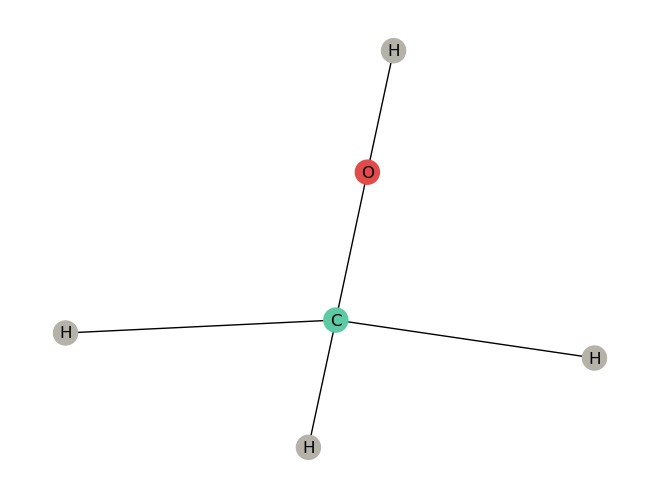

In [9]:
# Display the graph 
node_labels = {i : G.nodes[i]["element"] for i in range(len(G.nodes))}
color_map = {"C": "#5DCAA5", "O": "#E24B4A", "H": "#B4B2A9", "N": "#378ADD"}
node_colors = [color_map[G.nodes[i]["element"]] for i in G.nodes]
nx.draw(G, labels=node_labels, node_color=node_colors)

How to represent the graphical data as inputs to the network? We will convert the node and connectivity data into matrices using two properties of the graph: the _adjacency_ matrix and the _node feature_ matrix.

- Adjacency matrix is a N x N matrix where N is the number of nodes in the graph. It is a binary matrix where A[i,j] = 1 if there is an edge between nodes i and j. If there is no edge, then A[i,j] = 0. For undirected graphs, the adjacency matrix is symmetric. For directed graphs, it is not necessarily symmetric.
- Node feature vector is a N x d matrix where _d_ is the number of features corresponding to each node. In our case, the feature vector tells us which element the node corresponds to. 

In [10]:
# Compute the adjacency matrix 
A = nx.to_numpy_array(G)
print(A)

# Does it match the graphical relationship you defined earlier? 

[[0. 1. 0. 1. 1. 1.]
 [1. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]]


Designing the feature vector

The simplest feature vector is called the _one-hot_ encoding. Here we assign a unique integer to each element type (e.g. C=0, H=1, O=2). Then we will represent this integer as a binary vector of length equal to the number of unique elements (in our case, 3). So, carbon will be represented as [1, 0, 0], hydrogen as [0, 1, 0], and oxygen as [0, 0, 1].

In [11]:
def get_feature_vector(element_type):
    if element_type == "C":
        return np.array([1, 0, 0])
    elif element_type == "O":
        return np.array([0, 1, 0])
    elif element_type == "H":
        return np.array([0, 0, 1])
    else:
        raise ValueError("Unknown element type!")



In [12]:
X = np.array([get_feature_vector(G.nodes[i]["element"]) for i in G.nodes])
print(X)

[[1 0 0]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]]


# Permutation equivariance 
The key property of graph data is that the nodes are not ordered. This means that if we permute the order of the nodes, the graph should still represent the same molecule. Therefore, any function that operates on the graph should be invariant to permutations of the nodes. This is the key advantage of using graph neural networks: they are designed to be permutation invariant by construction.

In [13]:
A @ X

array([[0., 1., 3.],
       [1., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

## 3. The Graph Convolutional layer

<!-- Pointer:
     - Core idea: each node's new features = aggregate of its neighbors' features
     - Math:  H = ReLU( (A + I) @ X @ W )
         (A + I) -- adjacency with self-loops, so each node sees its own features too
         X       -- node features
         W       -- learnable weight matrix (the only parameters of the layer)
     - Why it satisfies permutation equivariance:
         * The same W is applied to every node's neighborhood
         * Sum/mean over neighbors is order-independent
     - Stacking layers expands the receptive field by one hop per layer (analogous to CNN)
     - For graph-level prediction, mean-pool over nodes -> permutation invariant readout
-->

In [ ]:
# Get the node feature vectors


In [ ]:
class GCNLayer(nn.Module):
    """One layer of:  H = ReLU((A + I) @ X @ W)"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear_layer = nn.Linear(in_dim, out_dim)
        pass

    def forward(self, X, A_hat):
        # TODO
        # 1. transform X with the linear layer
        X = self.linear_layer(X)
        # 2. left-multiply by A_hat to aggregate over neighbors
        P = A_hat @ X 
        # 3. apply ReLU
        out = nn.ReLU(P)
        return out 


class GCN(nn.Module):
    """Two GCN layers + mean-pool readout + linear classifier."""
    def __init__(self, in_dim, hidden_dim=32, num_classes=2):
        super().__init__()
        # TODO: gcn1, gcn2, classifier
        self.gcn_layer_1 = GCNLayer(in_dim, hidden_dim)
        self.gcn_layer_2 = GCNLayer(hidden_dim, hidden_dim)
        self.output_layer = nn.Linear(hidden_dim, num_classes)

    def forward(self, X, A):
        # TODO:
        # 1. add self-loops:  A_hat = A + I
        A_hat = A + torch.eye(A)
        # 2. pass through gcn1, then gcn2
        gcn1_out = self.gcn_layer_1(X, A_hat)
        gcn2_out = self.gcn_layer_2(gcn1_out, A_hat)
        # 3. mean-pool node features -> graph-level vector
        gcn2_out = gcn2_out.flatten()
        # 4. classifier head -> logits
        output = self.output_layer(gcn2_out)
        return output

## 4. Verify permutation equivariance numerically

<!-- Pointer:
     - Quick sanity check that the GCN really is permutation-invariant at the graph level
     - Take methanol, push it through the (untrained) GCN, get a prediction p1
     - Permute the nodes, push the permuted graph through the same GCN, get p2
     - p1 and p2 should be (numerically) identical
     - Important: this works WITHOUT training -- it's a structural property of the architecture,
       not something the model learns
-->

In [ ]:
# TODO:
#   - Instantiate an (untrained) GCN
#   - Run on (X, A)         -> p1
#   - Run on (X_perm, A_perm) -> p2
#   - Assert torch.allclose(p1, p2)

## 5. Experiment: train on MUTAG

<!-- Pointer: real-data experiment.
     - MUTAG: 188 small molecules, predict mutagenicity (binary)
     - Provide a dataset loader (parses the TU Dortmund file format)
     - Standard train/test split, train the GCN, report test accuracy
     - For comparison: also train an FC baseline that flattens (padded X, A) into a vector
       -> shows FC struggles to handle variable-size, unordered graph inputs
     - For 40 minutes in class, keep it light: train one model, look at the result
       Save the FC-vs-GCN comparison as a take-home exercise
-->

In [ ]:
# TODO: load MUTAG.
from torch_geometric.datasets import TUDataset
dataset = TUDataset(root="./MUTAG", name="MUTAG")
print(dataset)                  # info about the whole dataset
print(dataset[0])               # one molecule
print(dataset[0].x)             # node feature matrix
print(dataset[0].edge_index)    # bond list
print(dataset[0].y)             # 0 or 1

In [ ]:
# Convert MUTAG dataset into training and validation loader
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader


train_set, val_set, test_set = random_split(dataset=dataset, lengths=[0.6, 0.2, 0.2])

In [ ]:
batch_size = 24

training_dataloader = DataLoader(\
    dataset=train_set, \
    batch_size=batch_size, \
    shuffle=True, \
    num_workers=0\
)

validation_dataloader = DataLoader(\
    dataset=val_set,
    batch_size=batch_size,
    shuffle=True, \
    num_workers=0\
)


In [ ]:
num_epochs = 10 
model = GCN(in_dim=20)
optimiser = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
train_loss, val_loss = [], []

for i in range(num_epochs):
    for x, y in zip(training_dataloader, validation_dataloader):
        optimiser.zero_grad()
        output = model(x)
        loss = loss_fn(output, y)
        loss.backward()
        optimiser.step()
    
    print(i, loss)
        



## 6. Evaluation and discussion

<!-- Pointer:
     - Plot loss/accuracy curves
     - Discussion questions:
       * What would happen if we used an FC that consumed the flattened (X, A)?
       * Why isn't there a notion of "position" in a graph?
       * For protein contact graphs, would 2 GCN layers be enough? (No -- diameter much larger)
     - Foreshadow: sequences are yet another data type with their own ordering structure
       -> next module, transformers
-->

In [ ]:
# TODO: loss curve plot, test accuracy reporting

## 7. Submission

<!-- Pointer:
     - Students upload their final test accuracy + loss curve plot
     - Take-home (4-week project): try this on a different TUDataset or MoleculeNet dataset
-->